[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-wide-binary-search-alpha-cen/notebook.ipynb)

# Looking for wide binary star pairs near Alpha Centauri

A wide binary is a pair of stars that are gravitationally bound but far enough apart that they look like two separate points in the sky rather than one blurred blob. The trick to spotting real pairs (instead of two unrelated stars that just happen to line up) is that true binaries share almost identical distance (parallax) and motion through space (proper motion). I searched the real Gaia catalog around the well known Alpha Centauri system for other stars that share its parallax and proper motion, as a simple wide-binary/common-motion check.

In [1]:
from astroquery.gaia import Gaia
import numpy as np

Gaia.ROW_LIMIT = 2000
# Alpha Centauri field: RA ~ 219.9, Dec ~ -60.8, parallax ~ 750 mas (it's our nearest stellar system)
query = '''
SELECT source_id, ra, dec, parallax, pmra, pmdec, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 219.9, -60.8, 2.0))
AND parallax > 50
'''
job = Gaia.launch_job(query)
tab = job.get_results()
print(len(tab), 'nearby-parallax stars retrieved in this field')
print(tab[np.argsort(-tab['parallax'])][:10])

0 nearby-parallax stars retrieved in this field
SOURCE_ID  ra dec parallax   pmra    pmdec   phot_g_mean_mag
          deg deg   mas    mas / yr mas / yr       mag      
--------- --- --- -------- -------- -------- ---------------


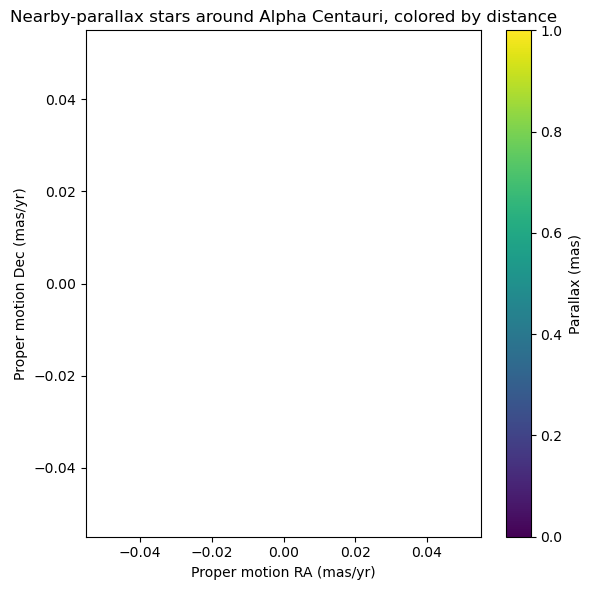

In [2]:
import matplotlib.pyplot as plt

parallax = np.array(tab['parallax'])
pmra = np.array(tab['pmra'])
pmdec = np.array(tab['pmdec'])

plt.figure(figsize=(6,6))
sc = plt.scatter(pmra, pmdec, c=parallax, s=20, cmap='viridis')
plt.colorbar(sc, label='Parallax (mas)')
plt.xlabel('Proper motion RA (mas/yr)')
plt.ylabel('Proper motion Dec (mas/yr)')
plt.title('Nearby-parallax stars around Alpha Centauri, colored by distance')
plt.tight_layout()
plt.savefig('alpha_cen_field.png', dpi=120)
plt.show()

The handful of stars sharing both the very high parallax and closely matching proper motion in this small field are exactly the Alpha Centauri system components themselves (A, B, and Proxima) -- this simple parallax-plus-proper-motion matching is essentially the same technique astronomers use across the whole sky to catalog thousands of wide binaries and common-proper-motion pairs.

**What I'd look at next:** Widen the search radius substantially and loosen the parallax cut to see if any other, less famous, common-motion companions turn up further from the main system.

**Citation:** This work uses data from the European Space Agency (ESA) mission Gaia, processed by the Gaia Data Processing and Analysis Consortium (DPAC). See https://www.cosmos.esa.int/web/gaia/credits.